# Spot Findr

This notebook matches spot coordinates to nuclear masks. It runs through a given series of experiments and does the following: 
1. reads in the spot detection files
2. reads the corresponding nuclear mask files
3. matches them to assign spots to nuclei/cells.

Based on that matching, it will create two data frames:
1. Spot metrics: lists the ROIs in each of the images, the XY coordinates for each of the spots within it and the fluorescence intensity for each spot in each fluorescence channel (also the "probability", inherited from Spotiflow).
2. Spot counts: lists the ROIs (nuclei/cells) in each of the images and the number of spots in that ROI in each fluorescent channel.

The notebook is intended to read in spot detection .csv files generated by Spotiflow and nuclear masks generated by Cellpose. Spot tables and masks generated by other tools should be valid too, but data formats and table structures should be verified and the code may need to be modified accordingly

In [1]:
# Import necessary packages

import os, glob, logging
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9 
import seaborn as sns
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define path names and data folders to process

# Define the location of the file to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # modify if needed
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory
experiment_list = ["08012025_Maria_FISH"]
#experiment_list = ["02112025_Cen-ZF_select_HCT116_session1", "02132025_Cen-ZF_select_HCT116_session2"]

#experiment_list = ["08052024_pDIMMERs", "08122024_pDIMMERs",
#                  "10032024_pDIMMERs", "10072024_pDIMMERs"]

#experiment_list = ["09042024_Cen-ZF_set3_session1", "09092024_Cen-ZF_set3_session2", 
#"09102024_Cen-ZF_set3_session3", "09122024_Cen-ZF_set3_session4", 
#"09172024_Cen-ZF_set3_session5", "09262024_Cen-ZF_set3_session6",
#"02032025_Cen-ZF_set4_session1", "02042025_Cen-ZF_set4_session2"] # this will be changed for each experiment

In [3]:
# Do some housekeeping first

# This dictionary defines the folder inside of "experiment" that contains masks
file_folders = {
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [ ]:
# CHUNK 1 # 
# Load segmentation masks for images 

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"mask_n": []},
        "file_names": {"mask_n": []},
        "base_names": {"mask_n": []},
        "errors": []
    }

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['mask_n'])} nuclei masks.")

In [ ]:
# CHUNK 2 #
# Load spot files for each image into a dictionary

# Initialize dictionary to store spot data across multiple experiments
all_experiments_spots = {}

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_spots = {
        "spot_files": {"spots": []},
        "spot_file_names": {"spots": []},
        "spot_base_names": {"spots": []},
        "spot_channels": [],
        "spot_errors": []
    }

    # Define the folder containing the spot files for the current experiment
    spots_folder = "spotiflow_results/"
    spots_path = os.path.join(parent_directory, experiment, spots_folder)

    # List all CSV files in the directory
    csv_files = glob.glob(os.path.join(spots_path, "*.csv"))

    # Read each CSV file and store the data and filename in the experiment's spot dictionary
    for file in csv_files:
        try:
            spots = pd.read_csv(file)  # Assumes a simple CSV structure; modify if necessary
            file_name = os.path.basename(file)

            # Extract the channel from the file name (e.g., C1, C2, etc.)
            # Assumes file name starts with C followed by a number (such as "C1-", "C2-", etc)
            channel = int(file_name.split('-')[0][1])  # Get the number after 'C'

            exp_spots["spot_files"]['spots'].append(spots)
            exp_spots["spot_file_names"]['spots'].append(file_name)  # Save the filename
            exp_spots["spot_base_names"]['spots'].append(extract_base_name(file_name))  # Store the base name
            exp_spots["spot_channels"].append(channel)  # Save the channel
            
        except Exception as e:
            exp_spots["spot_errors"].append(file)
            logging.error(f"Error reading {file} in {experiment}: {str(e)}")

    # Log completion for this experiment
    if exp_spots["spot_errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_spots['spot_errors'])} files.")
    else:
        logging.info(f"{experiment}: All spot files loaded successfully.")

    # Store the experiment's spot data in the main dictionary
    all_experiments_spots[experiment] = exp_spots

# Optional: Summary of processed spot files for all experiments
for experiment, data in all_experiments_spots.items():
    logging.info(f"{experiment}: Processed {len(data['spot_file_names']['spots'])} spot files.")


In [6]:
# CHUNK 3 #
# Match spot files to nuclear mask files using the base_names (common to all files) + channel (for spots on multiple channels)

# Initialize a dictionary to store matched indices for each experiment
all_matched_indices_with_spots = {}

# Loop through each experiment
for experiment in experiment_list:
    # Get the list of mask base_names and the list of spot base_names + their channels
    mask_base_names = all_experiments_data[experiment]["base_names"]["mask_n"]
    spot_base_names = all_experiments_spots[experiment]["spot_base_names"]["spots"]
    spot_channels   = all_experiments_spots[experiment]["spot_channels"]
    
    # Convert list of spot base names to a dictionary for faster lookup
    # CRITICAL: use both base name AND channel (as a single base name for masks may correspond to multiple spot files (one per channel))
    spot_name_to_index = {
        (base_name, channel): index
        for index, (base_name, channel) in enumerate(zip(spot_base_names, spot_channels))
    }

    matched_pairs = []
    missing_count = 0

    # For each nuclear mask, match to every spot file of the same base_name in each channel
    for mask_index, mask_base_name in enumerate(mask_base_names):
        found_match = False

        # Try matching this mask to each channel seen in this experiment
        for channel in set(spot_channels):
            key = (mask_base_name, channel)
            spot_index = spot_name_to_index.get(key)
            if spot_index is not None:
                matched_pairs.append((mask_index, spot_index))
                found_match = True

        if not found_match:
            missing_count += 1
            mask_filename = all_experiments_data[experiment]["file_names"]["mask_n"][mask_index]
            logging.warning(
                f"No matching spot files for mask `{mask_filename}` "
                f"in experiment `{experiment}`"
            )

    all_matched_indices_with_spots[experiment] = matched_pairs
    logging.info(
        f"{experiment}: matched {len(matched_pairs)} mask↔spot pairs; "
        f"{missing_count} masks with no spots"
    )

# Optional: summary across all experiments
for experiment, pairs in all_matched_indices_with_spots.items():
    logging.info(f"{experiment}: total {len(pairs)} matched mask–spot pairs")

2025-08-21 12:11:59,635 - INFO - 08012025_Maria_FISH: matched 39 mask↔spot pairs; 0 masks with no spots
2025-08-21 12:11:59,638 - INFO - 08012025_Maria_FISH: total 39 matched mask–spot pairs


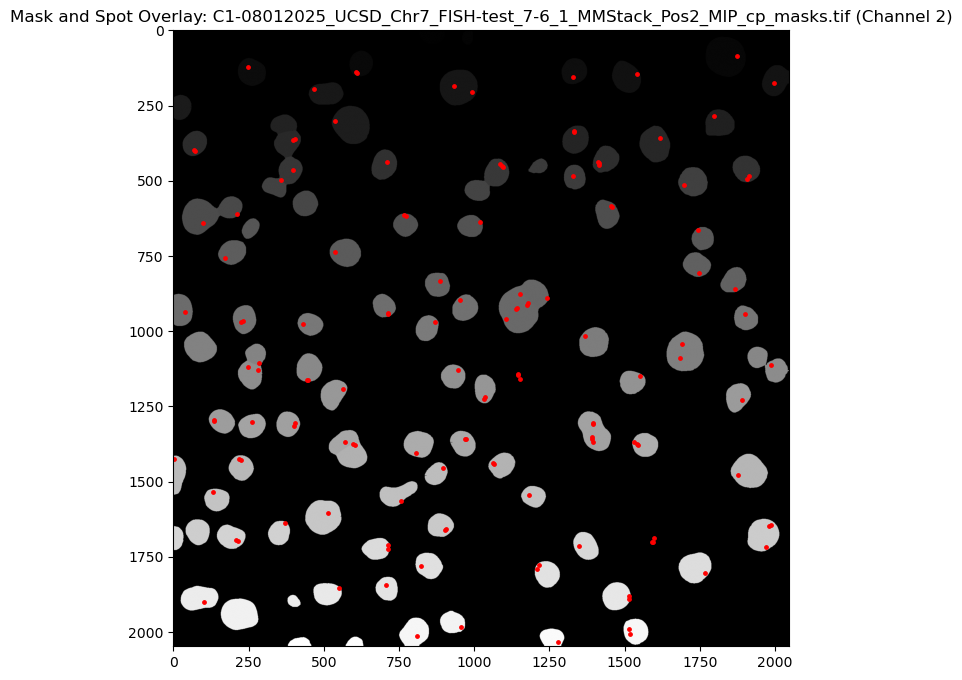

In [9]:
# Overlay a mask and its spot coordinates for visual confirmation that
# a) match was correct
# b) XY axes align on both images

# Pick an experiment from experiment_list, an image and a channel to overlay, using indices
e = 0 # index for experiment (from 0 to length(experiment_list - 1))
experiment = experiment_list[e]
i = 6 # image index (1 - (n images -1))
c = 2 # channel to overlay (1-index, from C1-, C2, C3-)

# Retrieve the matched indices for the selected experiment
matched_indices = all_matched_indices_with_spots[experiment]
mask_index, spot_index = matched_indices[i]

# Access mask and spot data for the chosen experiment and indices
mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
mask_base_name = all_experiments_data[experiment]['base_names']['mask_n'][mask_index]

# Find the corresponding spot file for the chosen channel
spot_found = False
for j, spot_base_name in enumerate(all_experiments_spots[experiment]['spot_base_names']['spots']):
    if spot_base_name == mask_base_name and all_experiments_spots[experiment]['spot_channels'][j] == c:
        spots = all_experiments_spots[experiment]['spot_files']['spots'][j]
        spot_found = True
        break

# Proceed with plotting if the corresponding spot file for the chosen channel is found
if spot_found:
    # The spot files have 'x' and 'y' as labels for columns containing coordinates
    x_coords = spots['x']
    y_coords = spots['y']

    # Plot the mask
    plt.figure(figsize=(8, 8))
    plt.imshow(mask, cmap='gray')
    plt.scatter(x_coords, y_coords, color='red', s=6)  # Overlay spots in red
    plt.title(f"Mask and Spot Overlay: {all_experiments_data[experiment]['file_names']['mask_n'][mask_index]} (Channel {c})")
    plt.show()
else:
    print(f"No spot data found for channel {c} at index {i} in experiment {experiment}.")

In [10]:
# CHUNK 4 (updated using base_names and multiple channels) #
# Assign each spot to a nuclear mask ROI based on their coordinates

# Generate a dictionary to hold the number of spots per ROI for all experiments
spot_counts_per_roi = {}
# and a list to store spot metrics data
spot_metrics_data = []

# Loop through each experiment
for experiment in experiment_list:
    # Retrieve matched base_name <-> channel pairs for the current experiment
    matched_pairs = all_matched_indices_with_spots[experiment]
    
    # Retrieve data for masks and spots for the current experiment
    mask_base_names = all_experiments_data[experiment]['base_names']['mask_n']
    masks           = all_experiments_data[experiment]['all_images']['mask_n']
    spot_files      = all_experiments_spots[experiment]['spot_files']['spots']
    spot_channels   = all_experiments_spots[experiment]['spot_channels']

    # Iterate through each matched pair, one at a time
    for mask_index, spot_index in matched_pairs:
        mask_base_name = mask_base_names[mask_index]
        my_mask        = masks[mask_index]
        spot_coords    = spot_files[spot_index]
        channel        = spot_channels[spot_index]
        
        # Get all unique ROI values in the mask (excluding background 0) and initialize them with zero spot count
        for roi in np.unique(my_mask):
            if roi == 0:
                continue
            key = (experiment, mask_base_name, roi, channel)
            spot_counts_per_roi.setdefault(key, 0)

        # Extract x, y, intensity, and probability from the spot file
        # Round the coordinates for indexing
        x_coords      = np.round(spot_coords['x']).astype(int)
        y_coords      = np.round(spot_coords['y']).astype(int)
        intensities   = spot_coords['intensity'].values
        probabilities = spot_coords['probability'].values

        # Assign each spot to an ROI in the mask based on coordinates, and record metrics
        for x, y, intensity, probability in zip(x_coords, y_coords, intensities, probabilities):
            if 0 <= y < my_mask.shape[0] and 0 <= x < my_mask.shape[1]:
                roi = my_mask[y, x]
                if roi == 0:
                    continue
                key = (experiment, mask_base_name, roi, channel)
                spot_counts_per_roi[key] += 1

                spot_metrics_data.append({
                    'experiment': experiment,
                    'base_name' : mask_base_name,
                    'ROI'       : roi,
                    'channel'   : channel,
                    'x'         : x,
                    'y'         : y,
                    'intensity': intensity,
                    'probability': probability
                })

In [11]:
# Convert the dictionaries above to Pandas data frames

# Create a DataFrame from the spot_counts dictionary 
# that contains spot counts for each ROI in each image and channel
spot_counts = pd.DataFrame([
    {
        'experiment': experiment,
        'base_name': base_name,
        'ROI': roi,
        'channel': channel,
        'spot_count': count
    }
    for (experiment, base_name, roi, channel), count in spot_counts_per_roi.items()
])

# Convert the spot_metrics list to a second data frame, 
# that contains the x, y, intensity and probabilty for each spot with assigned ROI, image and channel
spot_metrics = pd.DataFrame(spot_metrics_data)

In [12]:
# Display a sample of each DataFrame for inspection
print("Spot Counts DataFrame:")
print(spot_counts.head(10))
print("\nSpot Metrics DataFrame:")
print(spot_metrics.head(10))

Spot Counts DataFrame:
            experiment                                          base_name  \
0  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
1  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
2  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
3  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
4  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
5  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
6  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
7  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
8  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
9  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   

   ROI  channel  spot_count  
0    1        2           2  
1    2        2           4  
2    3        2           0  
3    4   

In [13]:
# Check that each image has spot information for all relevant channels:
# 1) Count how many unique channels each image has
channels_per_image = (
    spot_metrics
    .groupby('base_name')['channel']
    .nunique()
    .reset_index(name='n_channels')
)

# 2) Show the distribution of channel counts
print(channels_per_image['n_channels'].value_counts().sort_index())

n_channels
1    39
Name: count, dtype: int64


In [14]:
# CHUNK 5 #
# Read in the experimental groups reference files for each experiment (metadata)

# Initialize a list to hold the experimental group DataFrames for each experiment
exp_groups_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    csv_path = os.path.join(parent_directory, experiment, "experimental-groups.csv")
    try:
        # Read the CSV file
        exp_df = pd.read_csv(csv_path)
        
        # If the file contains a column called "experiment_folder", rename it to "experiment"
        if 'experiment_folder' in exp_df.columns:
            exp_df = exp_df.rename(columns={'experiment_folder': 'experiment'})
        
        # If neither "experiment_folder" nor "experiment" is present, create a new column
        if 'experiment' not in exp_df.columns:
            exp_df['experiment'] = experiment
        
        # Append the DataFrame to the list
        exp_groups_list.append(exp_df)
        
    except Exception as e:
        logging.error(f"Error reading {csv_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
exp_groups = pd.concat(exp_groups_list, ignore_index=True)

# Update the "filename" column in experimental_groups by replacing ".ome.tif" at the end with "_MIP"
# to match the format of other tables
exp_groups['filename'] = exp_groups['filename'].str.replace(r'\.ome\.tif$', '_MIP', regex=True)

# Rename "filename" to "base_name" as in spots counts file
exp_groups.rename(columns = {"filename": "base_name"}, inplace = True)

# Optionally, inspect the combined DataFrame
print(exp_groups.head())

            experiment                                          base_name  \
0  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-2_1_MMStack_Pos...   
1  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-2_1_MMStack_Pos...   
2  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-2_1_MMStack_Pos...   
3  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-2_1_MMStack_Pos...   
4  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-2_1_MMStack_Pos...   

     plasmid group  
0  Cen7-ZF1g  rep2  
1  Cen7-ZF1g  rep2  
2  Cen7-ZF1g  rep2  
3  Cen7-ZF1g  rep2  
4  Cen7-ZF1g  rep2  


In [15]:
# Optional: print an instance of base_name from exp_groups and spot_counts 
# to confirm format matches
print(exp_groups['base_name'][0])
print(spot_counts['base_name'][0])

08012025_UCSD_Chr7_FISH-test_7-2_1_MMStack_Pos0_MIP
08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos6_MIP


In [16]:
# Optional: incorporate exp_groups metadata into spot_counts and spot_metrics data frames
# >> you'll want to do this if your exp_groups file has more information than "experiment" and "base_name"
spot_counts = pd.merge(spot_counts, 
                       exp_groups, 
                       on = ["experiment", "base_name"], how = 'left')
spot_metrics = pd.merge(spot_metrics, 
                       exp_groups, 
                       on = ["experiment", "base_name"], how = 'left')

In [17]:
print(spot_counts.head())
print(spot_metrics.head())

            experiment                                          base_name  \
0  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
1  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
2  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
3  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
4  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   

   ROI  channel  spot_count    plasmid group  
0    1        2           2  Cen7-ZF1g  rep3  
1    2        2           4  Cen7-ZF1g  rep3  
2    3        2           0  Cen7-ZF1g  rep3  
3    4        2           1  Cen7-ZF1g  rep3  
4    5        2           1  Cen7-ZF1g  rep3  
            experiment                                          base_name  \
0  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
1  08012025_Maria_FISH  08012025_UCSD_Chr7_FISH-test_7-3_1_MMStack_Pos...   
2  08012025_Maria_FISH  

In [18]:
# FILE SAVING # 

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Files for each experiment will be saved in their own folder as .csv files
# They can subsequently be read in and joined as needed
# This is more versatile than combining data from multiple experiments into a single big .csv file

# Get today's date string to use as a suffix
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    experiment_folder = os.path.join(results_dir, experiment)
    
    # Create the folder if it doesn't already exist
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the DataFrames for the current experiment.
    # (Assumes your spot_counts and spot_metrics DataFrames include an "experiment" column.)
    spot_counts_exp = spot_counts[spot_counts['experiment'] == experiment]
    spot_metrics_exp = spot_metrics[spot_metrics['experiment'] == experiment]
    
    # Define the default file paths for the CSV files
    spot_counts_file = os.path.join(experiment_folder, "spot_counts-raw.csv")
    spot_metrics_file = os.path.join(experiment_folder, "spot_metrics-raw.csv")
    
    # If the spot_counts file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_counts_file):
        spot_counts_file = os.path.join(experiment_folder, f"spot_counts_{date_suffix}.csv")
    
    # If the spot_metrics file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_metrics_file):
        spot_metrics_file = os.path.join(experiment_folder, f"spot_metrics_{date_suffix}.csv")
    
    # Save the DataFrames to their respective CSV files
    spot_counts_exp.to_csv(spot_counts_file, index=False)
    spot_metrics_exp.to_csv(spot_metrics_file, index=False)

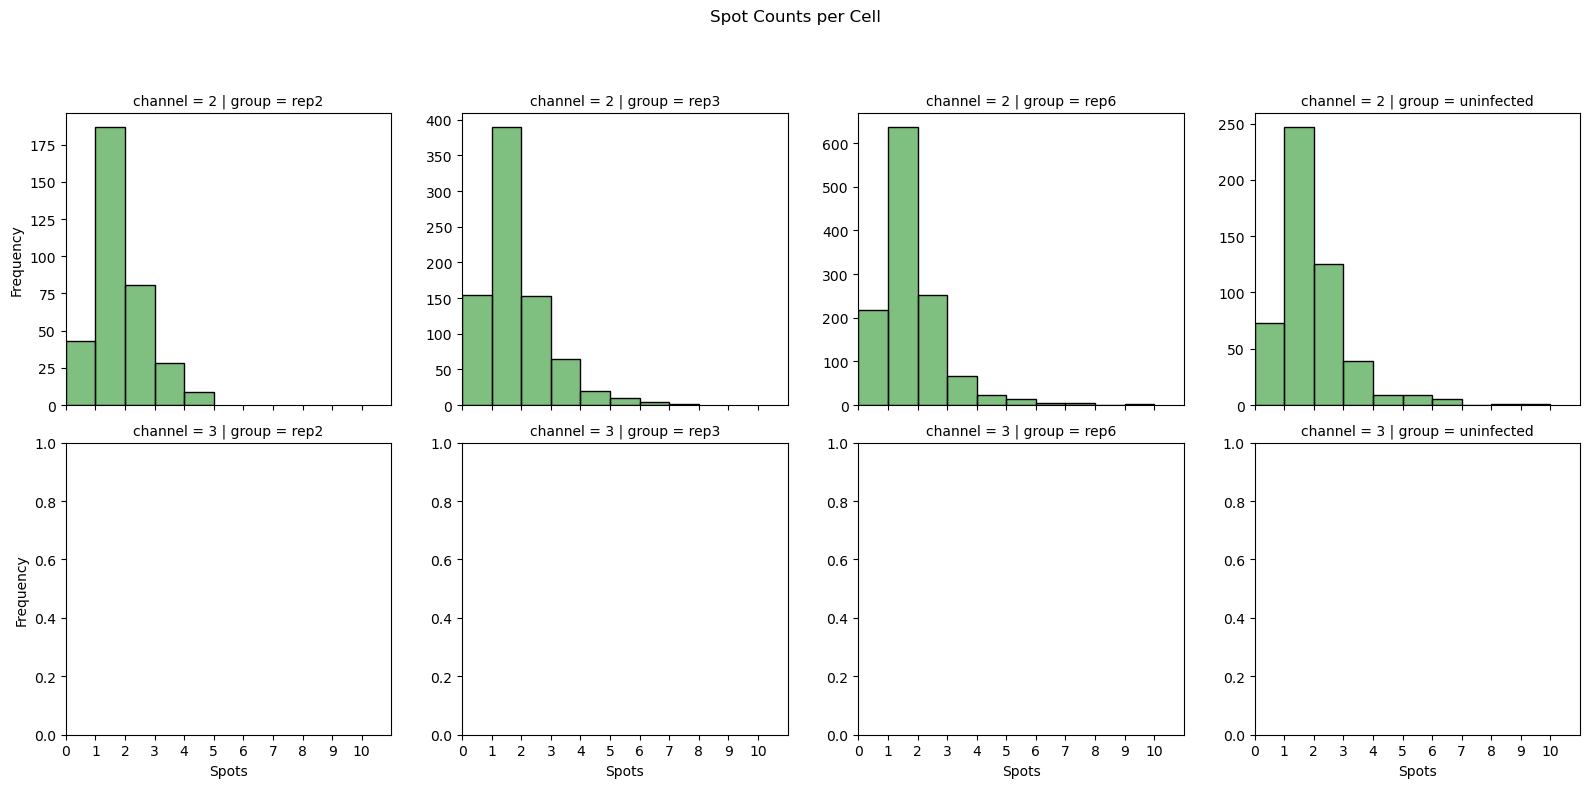

In [19]:
# VISUALIZATION #

# Define a dictionary of channel colors
channel_colors = {1: 'blue', 2: 'green', 3: 'magenta', 4: 'cyan'}

# Plot the number of spots found for all ROIs in all images, 
# separated by experimental group and channel

# Define the subset of data to plot
my_spots = spot_counts[(spot_counts['experiment'] == experiment_list[0]) & 
                       (spot_counts['channel'].isin([2,3]))]

# Define the variable to facet by on the columns
# the rows will always be the "channel" variable
facet_var = "group" # change this as you wish

# Determine the largest number of spots to set the X axis of the plot
#max_spot_count = spot_df['spot_count'].max()
max_spot_count = 10

# Optionally, define a fixed order for channels and the facet variable.
channel_order = [2, 3]  # adjust as needed
# For facet variable, you might define an explicit order or use sorted unique values.
facet_order = sorted(my_spots[facet_var].unique())

# Create bins: bins from 0 to max_spot_count+1 so that there are (max_spot_count+1) bins.
bins = list(range(0, max_spot_count + 2))
# Calculate bin midpoints (e.g., 0.5, 1.5, ..., max_spot_count + 0.5 - but we only need up to max_spot_count)
bin_midpoints = [x + 0.5 for x in range(0, max_spot_count + 1)]

# Convert columns to categorical to enforce the ordering.
my_spots = my_spots.copy()  # work on a copy if needed
my_spots["channel"] = pd.Categorical(my_spots["channel"], categories=channel_order, ordered=True)
my_spots[facet_var] = pd.Categorical(my_spots[facet_var], categories=facet_order, ordered=True)

# Let the user control the number of columns in the facet wrap.
desired_ncols = 2  # You can change this number as desired

# Create a FacetGrid using the combined variable, with col_wrap to force a wrap.
g = sns.FacetGrid(my_spots, row = "channel", col=facet_var, sharey=False, height=4, aspect=1)

# Map a histogram for each panel.
g.map_dataframe(
    sns.histplot,
    x="spot_count",
    binwidth=1,
    bins=bins,
    hue="channel",
    palette= channel_colors,
    edgecolor="black",
    alpha=0.5
)

# Adjust each axis: set x-limits, centered tick marks, and ensure full panel borders.
for ax in g.axes.flat:
    ax.set_xlim(0, max_spot_count + 1)
    ax.set_xticks(range(0, max_spot_count + 1))
    # Ensure all four spines are visible
    for spine in ax.spines.values():
        spine.set_visible(True)

# Set labels and title
g.set_axis_labels("Spots", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Spot Counts per Cell")

plt.show()